# 1. General Overview

Load dataset, ensure that it works also from another computer

In [15]:
# If any import fails, run e.g.:
# %pip install pandas plotly

from pathlib import Path
import pandas as pd
import numpy as np
import plotly.express as px

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)


In [16]:
# Works whether you run the notebook from repo root or /notebook/
cwd = Path.cwd()
root = cwd if (cwd / "data").exists() else cwd.parent

candidates = [
    root / "data" / "mind@work" / "mental_health_dataset" / "Cleaned_remote_work.csv",
    root / "data" / "mind@work" / "mental heath dataset" / "Cleaned_remote_work.csv",  # legacy typo
]

data_file = next((p for p in candidates if p.exists()), None)
assert data_file is not None, f"Dataset not found. Checked:\n- " + "\n- ".join(map(str, candidates))
data_file


PosixPath('/Users/huongle/Documents/GitHub/Mind_At_Work_Website/data/mind@work/mental_health_dataset/Cleaned_remote_work.csv')

In [17]:
df = pd.read_csv(data_file)
print(f"rows: {len(df):,} | cols: {df.shape[1]}")
df.head()

rows: 5,000 | cols: 19


,Age,Gender,Job_Role,Industry,Years_of_Experience,Work_Location,Hours_Worked_Per_Week,Number_of_Virtual_Meetings,Work_Life_Balance_Rating,Stress_Level,Mental_Health_Condition,Access_to_Mental_Health_Resources,Productivity_Change,Social_Isolation_Rating,Satisfaction_with_Remote_Work,Company_Support_for_Remote_Work,Physical_Activity,Sleep_Quality,Region
0,32,Non-binary,HR,Healthcare,13,Hybrid,47,7,2,Medium,Depression,No,Decrease,1,Unsatisfied,1,Weekly,Good,Europe
1,40,Female,Data Scientist,IT,3,Remote,52,4,1,Medium,Anxiety,No,Increase,3,Satisfied,2,Weekly,Good,Asia
2,59,Non-binary,Software Engineer,Education,22,Hybrid,46,11,5,Medium,Anxiety,No,No Change,4,Unsatisfied,5,NaN,Poor,North America
3,27,Male,Software Engineer,Finance,20,Onsite,32,8,4,High,Depression,Yes,Increase,3,Unsatisfied,3,NaN,Poor,Europe
4,49,Male,Sales,Consulting,32,Onsite,35,12,2,High,NaN,Yes,Decrease,3,Unsatisfied,3,Weekly,Average,North America


In [18]:
print("Dataset shape:", df.shape)
df.info()
df.describe()

Dataset shape: (5000, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   Age                                5000 non-null   int64 
 1   Gender                             5000 non-null   object
 2   Job_Role                           5000 non-null   object
 3   Industry                           5000 non-null   object
 4   Years_of_Experience                5000 non-null   int64 
 5   Work_Location                      5000 non-null   object
 6   Hours_Worked_Per_Week              5000 non-null   int64 
 7   Number_of_Virtual_Meetings         5000 non-null   int64 
 8   Work_Life_Balance_Rating           5000 non-null   int64 
 9   Stress_Level                       5000 non-null   object
 10  Mental_Health_Condition            3804 non-null   object
 11  Access_to_Mental_Health_Resources  5000 non

,Age,Years_of_Experience,Hours_Worked_Per_Week,Number_of_Virtual_Meetings,Work_Life_Balance_Rating,Social_Isolation_Rating,Company_Support_for_Remote_Work
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,40.995000,17.810200,39.614600,7.559000,2.984200,2.993800,3.007800
std,11.296021,10.020412,11.860194,4.636121,1.410513,1.394615,1.399046
min,22.000000,1.000000,20.000000,0.000000,1.000000,1.000000,1.000000
25%,31.000000,9.000000,29.000000,4.000000,2.000000,2.000000,2.000000
50%,41.000000,18.000000,40.000000,8.000000,3.000000,3.000000,3.000000
75%,51.000000,26.000000,50.000000,12.000000,4.000000,4.000000,4.000000
max,60.000000,35.000000,60.000000,15.000000,5.000000,5.000000,5.000000


For descriptive analysis (EDA): i will leave them as object. Pandas .value_counts() and Seaborn plots work fine. But later for modelling like classification, they should have categorical as datatype.

In [46]:
df["Physical_Activity"] = df["Physical_Activity"].fillna("No Activity")
df["Mental_Health_Condition"] = df["Mental_Health_Condition"].fillna("No Condition")
# Confirm fixes
print(df.isna().sum())

Age                                  0
Gender                               0
Job_Role                             0
Industry                             0
Years_of_Experience                  0
Work_Location                        0
Hours_Worked_Per_Week                0
Number_of_Virtual_Meetings           0
Work_Life_Balance_Rating             0
Stress_Level                         0
Mental_Health_Condition              0
Access_to_Mental_Health_Resources    0
Productivity_Change                  0
Social_Isolation_Rating              0
Satisfaction_with_Remote_Work        0
Company_Support_for_Remote_Work      0
Physical_Activity                    0
Sleep_Quality                        0
Region                               0
dtype: int64


## 2. Distribution of Variables

- Categorical variables

In [20]:
pd.set_option("display.max_rows", None)

for col in df.select_dtypes(include=["object", "category"]).columns:
    print(f"\n{col} value counts (%):")
    print(df[col].value_counts(normalize=True) * 100)


Gender value counts (%):
Gender
Female               25.48
Male                 25.40
Prefer not to say    24.84
Non-binary           24.28
Name: proportion, dtype: float64

Job_Role value counts (%):
Job_Role
Project Manager      14.76
Sales                14.66
Designer             14.46
HR                   14.32
Software Engineer    14.22
Data Scientist       13.92
Marketing            13.66
Name: proportion, dtype: float64

Industry value counts (%):
Industry
Finance          14.94
IT               14.92
Healthcare       14.56
Retail           14.52
Education        13.80
Manufacturing    13.66
Consulting       13.60
Name: proportion, dtype: float64

Work_Location value counts (%):
Work_Location
Remote    34.28
Hybrid    32.98
Onsite    32.74
Name: proportion, dtype: float64

Stress_Level value counts (%):
Stress_Level
High      33.72
Medium    33.38
Low       32.90
Name: proportion, dtype: float64

Mental_Health_Condition value counts (%):
Mental_Health_Condition
Burnout        

This dataset looks synthetically balanced

In [21]:
cat_cols = ["Work_Life_Balance_Rating", 
            "Social_Isolation_Rating", 
            "Company_Support_for_Remote_Work"]

for col in cat_cols:
    print(f"\n{col} value counts (%):")
    print(df[col].value_counts(normalize=True) * 100)


Work_Life_Balance_Rating value counts (%):
Work_Life_Balance_Rating
3    21.06
1    20.46
4    19.60
5    19.54
2    19.34
Name: proportion, dtype: float64

Social_Isolation_Rating value counts (%):
Social_Isolation_Rating
2    21.32
4    20.74
3    19.84
1    19.06
5    19.04
Name: proportion, dtype: float64

Company_Support_for_Remote_Work value counts (%):
Company_Support_for_Remote_Work
3    21.54
5    19.74
2    19.70
4    19.68
1    19.34
Name: proportion, dtype: float64


###  Distribution of mental health condition

**We will run a couple plots to see the distrbutions on variables that are deemed important to measure ratings and  mental health conditions.**

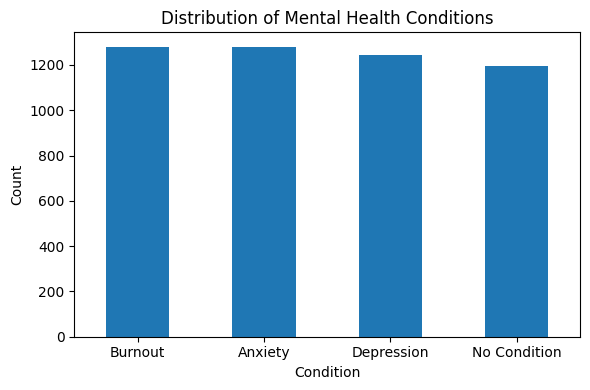

In [22]:
import matplotlib.pyplot as plt

ax = (
    df["Mental_Health_Condition"]
      .fillna("None")
      .value_counts()
      .plot(kind="bar", figsize=(6,4))
)
ax.set_title("Distribution of Mental Health Conditions")
ax.set_xlabel("Condition")
ax.set_ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


The distribution shows Burnout, Anxiety, Depression, and No Condition are almost equal in count. Roughly 3 in 4 people fall into an anxiety, burnout, or depression category, with only about 1 in 4 reporting no condition. That’s a strong signal of distress in this sample; it’s useful for analysis but likely overstates real-world prevalence.

### Distrubution of stress level

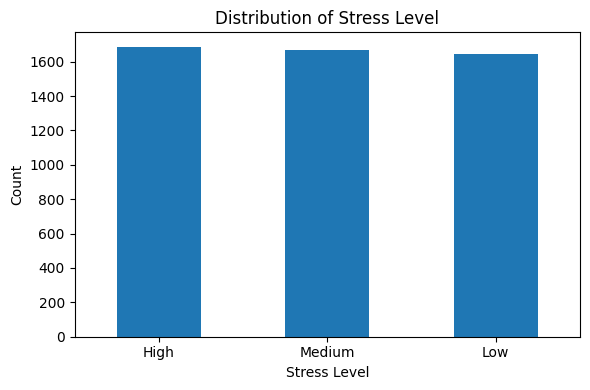

In [23]:
ax = (
    df["Stress_Level"]
      .fillna("None")
      .value_counts()
      .plot(kind="bar", figsize=(6,4))
)
ax.set_title("Distribution of Stress Level")
ax.set_xlabel("Stress Level")
ax.set_ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

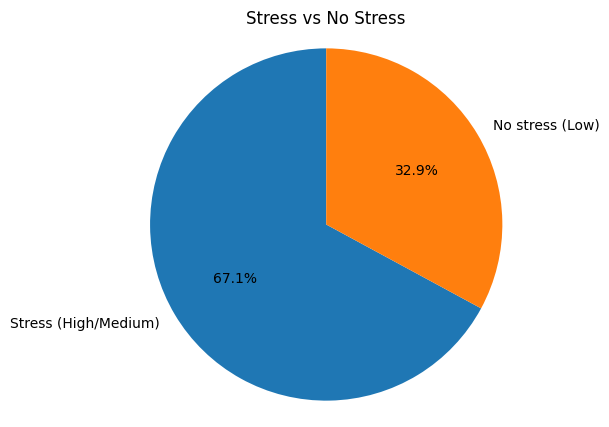

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# pick the right column name (adjust if yours differs)
for c in ["Stress Level", "Stress_Level", "stress_level", "Stress"]:
    if c in df.columns:
        STRESS_COL = c
        break
else:
    raise KeyError("Could not find a stress column in df.")

# clean + group
s = (df[STRESS_COL].astype("string").str.strip().str.title())
stress_mask = s.isin(["High", "Medium"])
labels = ["Stress (High/Medium)", "No stress (Low)"]
sizes = [int(stress_mask.sum()), int((~stress_mask).sum())]

# pie (donut style)
fig, ax = plt.subplots(figsize=(5,5))
ax.pie(
    sizes, labels=labels, startangle=90,
    autopct=lambda p: f"{p:.1f}%"
)
ax.set_title("Stress vs No Stress")
ax.axis("equal")
plt.show()


About one-third of people fall into each stress level-high, medium, and low-so high stress is as common as low stress in this sample. That even split is helpful for modeling but likely reflects a balanced/curated dataset, not real-world prevalence.

### Distribution of Productivity change

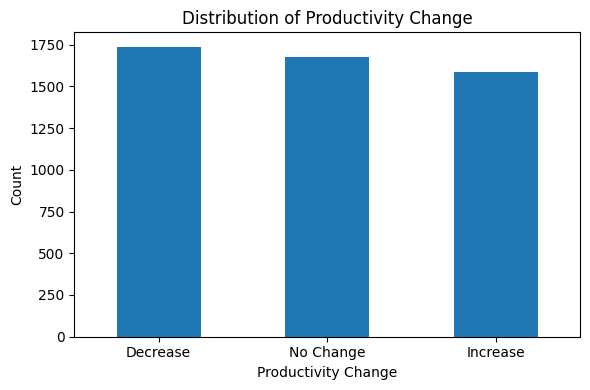

In [25]:
ax = (
    df["Productivity_Change"]
      .fillna("None")
      .value_counts()
      .plot(kind="bar", figsize=(6,4))
)
ax.set_title("Distribution of Productivity Change")
ax.set_xlabel("Productivity Change")
ax.set_ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Roughly one-third report a productivity decrease, one-third report no change, and slightly fewer than one-third report an increase, a small tilt toward decline. In plain terms: more people feel less productive than more productive.

# 3. WORK PATTERNS

### Q1. People work remote

70% people work remote having mental health problem

In [47]:
import matplotlib.pyplot as plt
import importlib
importlib.reload(plt)

<module 'matplotlib.pyplot' from '/Users/huongle/Documents/GitHub/Mind_At_Work_Website/.venv/lib/python3.12/site-packages/matplotlib/pyplot.py'>

In [49]:
import plotly.express as px

remote_df = df[df["Work_Location"] == "Remote"].copy()
mh_counts = remote_df["Mental_Health_Condition"].value_counts().reset_index()
mh_counts.columns = ["Condition", "Count"]

fig = px.pie(
    mh_counts,
    names="Condition",
    values="Count",
    hole=0,  # set >0 for donut
    title="Mental Health Conditions among Remote Workers",
    color_discrete_sequence=["#FFB3B3", "#FFCC99", "#99CCFF", "#D9D9D9"]
)
fig.update_traces(textposition="inside", textinfo="percent+label", pull=[0.05]*len(mh_counts))
fig.update_layout(showlegend=True)
fig.show()


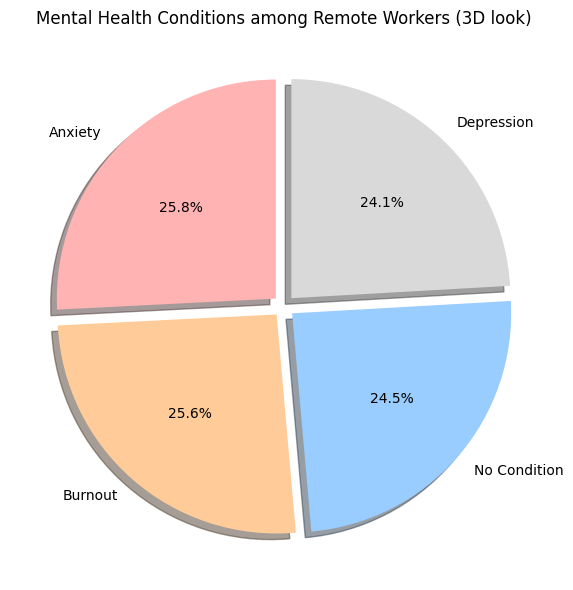

In [ ]:
remote_df = df[df["Work_Location"] == "Remote"].copy()
mh_counts = remote_df["Mental_Health_Condition"].value_counts()
mh_percent = (mh_counts / mh_counts.sum() * 100).round(1)

explode = [0.05] * len(mh_percent)

plt.figure(figsize=(6,6))
plt.pie(
    mh_percent,
    labels=mh_percent.index,
    autopct="%1.1f%%",
    startangle=90,
    shadow=True,
    explode=explode,
    colors=["#FFB3B3", "#FFCC99", "#99CCFF", "#D9D9D9"]
)
plt.title("Mental Health Conditions among Remote Workers")
plt.tight_layout()
plt.show()


### Q2. How many people work remote?

Nearly half of people who work remote need to work more than 40 hours per week

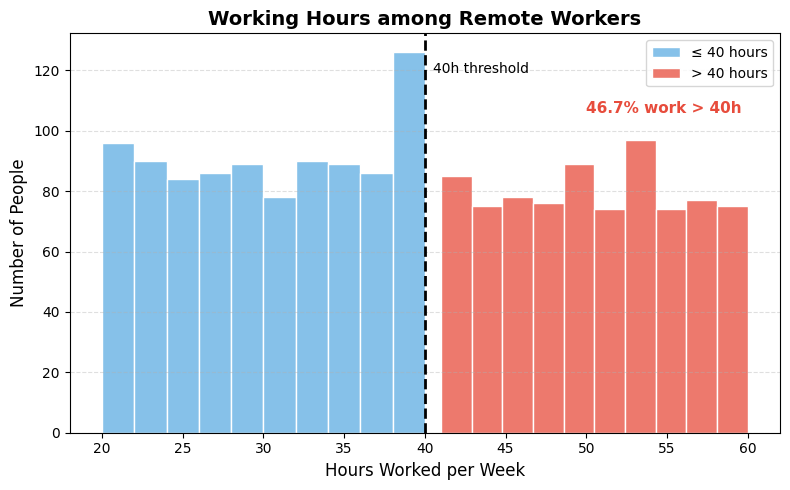

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- Data ---
remote_df = df[df["Work_Location"] == "Remote"].copy()
hours = remote_df["Hours_Worked_Per_Week"]

# --- Split data into <=40 and >40 ---
below_40 = hours[hours <= 40]
above_40 = hours[hours > 40]

# --- Plot setup ---
plt.figure(figsize=(8,5))

# Two histograms: before and after 40 hours
sns.histplot(below_40, bins=10, color="#5DADE2", edgecolor="white", label="≤ 40 hours")
sns.histplot(above_40, bins=10, color="#E74C3C", edgecolor="white", label="> 40 hours")

# Threshold line
plt.axvline(40, color="black", linestyle="--", linewidth=2)
plt.text(40.5, plt.ylim()[1]*0.9, "40h threshold", color="black", fontsize=10)

# Titles & labels
plt.title("Working Hours among Remote Workers", fontsize=14, weight="bold")
plt.xlabel("Hours Worked per Week", fontsize=12)
plt.ylabel("Number of People", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.legend()

# Annotate overwork rate
overwork_rate = (hours > 40).mean() * 100
plt.text(50, plt.ylim()[1]*0.8, f"{overwork_rate:.1f}% work > 40h", color="#E74C3C", fontsize=11, weight="bold")

plt.tight_layout()
plt.show()


Version for website

In [62]:
# --- Remote workers: beautiful histogram for website (Plotly) ---
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px

def remote_hours_hist_website(df: pd.DataFrame, threshold: int = 40):
    # Filter remote
    rem = df.loc[df["Work_Location"] == "Remote", "Hours_Worked_Per_Week"].dropna()

    # Split
    le_mask = rem <= threshold
    gt_mask = rem > threshold
    le = rem[le_mask]
    gt = rem[gt_mask]

    # Percent overwork
    over_pct = (gt.size / rem.size) * 100 if rem.size else 0

    # Nice bins that align at the threshold
    bin_edges = np.linspace(rem.min(), rem.max(), 16)

    # Colors (works well on light or dark themes)
    c_normal = "#6AA9FF"   # blue
    c_over   = "#F76D6D"   # coral/red

    fig = go.Figure()

    # Normal (≤ threshold)
    fig.add_trace(go.Histogram(
        x=le,
        name=f"≤ {threshold} hours",
        nbinsx=len(bin_edges)-1,
        xbins=dict(start=float(bin_edges.min()),
                   end=float(bin_edges.max()),
                   size=float((bin_edges.max()-bin_edges.min())/(len(bin_edges)-1))),
        marker=dict(color=c_normal, line=dict(width=0)),
        opacity=0.95,
        hovertemplate="Hours: %{x}<br>Count: %{y}<extra></extra>"
    ))

    # Overwork (> threshold)
    fig.add_trace(go.Histogram(
        x=gt,
        name=f"> {threshold} hours",
        nbinsx=len(bin_edges)-1,
        xbins=dict(start=float(bin_edges.min()),
                   end=float(bin_edges.max()),
                   size=float((bin_edges.max()-bin_edges.min())/(len(bin_edges)-1))),
        marker=dict(color=c_over, line=dict(width=0)),
        opacity=0.95,
        hovertemplate="Hours: %{x}<br>Count: %{y}<extra></extra>"
    ))

    # Vertical line at threshold
    fig.add_vline(
        x=threshold, line_width=2, line_dash="dash", line_color="#222",
        annotation_text=f"{threshold} h", annotation_position="top"
    )

    # Annotation with overwork percentage
    fig.add_annotation(
        text=f"<b>{over_pct:.1f}% work &gt; {threshold}h</b>",
        x=threshold + (rem.max()-threshold)*0.65,
        y=1.05, xref="x", yref="paper",
        showarrow=False, font=dict(size=16, color=c_over),
        bgcolor="rgba(255,255,255,0.6)", bordercolor=c_over, borderwidth=1
    )

    fig.update_layout(
        title=dict(
            text="Weekly Working Hours — Remote Workers",
            x=0.02, xanchor="left", y=0.95
        ),
        barmode="overlay",
        bargap=0.08,
        template="simple_white",
        xaxis_title="Hours Worked per Week",
        yaxis_title="Number of People",
        legend=dict(orientation="h", y=1.15, x=0.0),
        margin=dict(l=20, r=20, t=70, b=40),
        hoverlabel=dict(bgcolor="white"),
    )



# --- Example usage (Jupyter/Notebook) ---
# fig, over_pct = remote_hours_hist_website(df, threshold=40)
# fig.show()

# --- Streamlit usage ---
# import streamlit as st
# fig, over_pct = remote_hours_hist_website(df, threshold=40)
# st.plotly_chart(fig, use_container_width=True)
# st.caption(f"Summary: Among remote workers, {over_pct:.1f}% work more than 40 hours per week.")


In [61]:
fig.update_layout(
    legend=dict(orientation="h", y=-0.2, x=0.0),   # move under plot
    margin=dict(l=20, r=20, t=70, b=80),          # extra bottom space
    title=dict(text="Weekly Working Hours in Remote Workers", y=0.96, x=0.02)
)


# 4. Well-being indicator

### Q1. Employee received more company support feel more sastifaction

In [63]:
# Group by satisfaction and compute mean company support rating
support_by_satisfaction = (
    df.groupby("Satisfaction_with_Remote_Work")["Company_Support_for_Remote_Work"]
      .mean()
      .round(2)
      .sort_values(ascending=False)
)
support_by_satisfaction


Satisfaction_with_Remote_Work
Satisfied      3.05
Neutral        3.00
Unsatisfied    2.97
Name: Company_Support_for_Remote_Work, dtype: float64

/var/folders/7m/_vb5phg50tdbns11bkg8wskr0000gn/T/ipykernel_54705/3942131153.py:16: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/var/folders/7m/_vb5phg50tdbns11bkg8wskr0000gn/T/ipykernel_54705/3942131153.py:37: UserWarning:

Glyph 128153 (\N{BLUE HEART}) missing from font(s) DejaVu Sans.

/Users/huongle/Documents/GitHub/Mind_At_Work_Website/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:152: UserWarning:

Glyph 128153 (\N{BLUE HEART}) missing from font(s) DejaVu Sans.



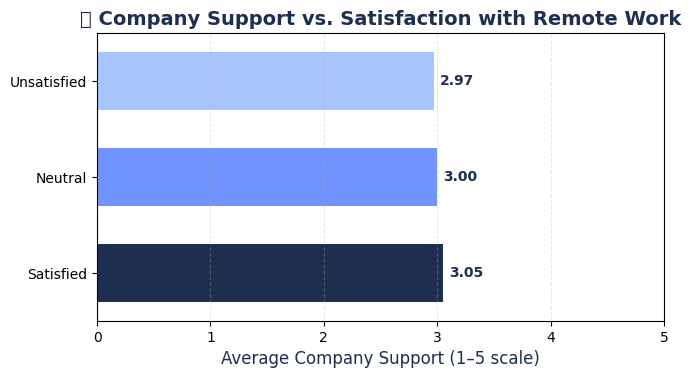

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Prepare data ---
support_by_satisfaction = (
    df.groupby("Satisfaction_with_Remote_Work")["Company_Support_for_Remote_Work"]
      .mean()
      .reset_index()
      .sort_values("Company_Support_for_Remote_Work", ascending=True)
)

# --- Styling ---
plt.figure(figsize=(7,4))
bar_colors = ["#A8C5FF", "#6F93FF", "#1E2E4F"]  # light → medium → dark blue

sns.barplot(
    data=support_by_satisfaction,
    x="Company_Support_for_Remote_Work",
    y="Satisfaction_with_Remote_Work",
    palette=bar_colors,
    saturation=1,
    width=0.6,   # thinner bars for more space between them
)

# --- Labels & Titles ---
plt.title("Company Support vs. Satisfaction with Remote Work", fontsize=14, weight="bold", color="#1E2E4F")
plt.xlabel("Average Company Support (1–5 scale)", fontsize=12, color="#1E2E4F")
plt.ylabel("")
plt.xlim(0, 5)
plt.grid(axis="x", linestyle="--", alpha=0.3)

# Add value labels
for i, val in enumerate(support_by_satisfaction["Company_Support_for_Remote_Work"]):
    plt.text(val + 0.05, i, f"{val:.2f}", va="center", fontsize=10, color="#1E2E4F", weight="bold")

# --- Adjust spacing ---
plt.tight_layout(pad=1.5)
plt.show()


But the gap doesn't look much

### Q2. Radar chart

In [69]:
import plotly.graph_objects as go
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# --- Map & prepare ---
df_radar = df.copy()
stress_map = {"Low": 3, "Medium": 2, "High": 1}
satisfaction_map = {"Unsatisfied": 1, "Neutral": 2, "Satisfied": 3}
df_radar["Stress_Score"] = df_radar["Stress_Level"].map(stress_map)
df_radar["Satisfaction_Score"] = df_radar["Satisfaction_with_Remote_Work"].map(satisfaction_map)
df_radar["Social_Isolation_Rating"] = 6 - df_radar["Social_Isolation_Rating"]

data = df_radar.groupby("Work_Location")[[
    "Work_Life_Balance_Rating",
    "Company_Support_for_Remote_Work",
    "Social_Isolation_Rating",
    "Stress_Score",
    "Satisfaction_Score"
]].mean()

# --- Normalize 0–5 range for better visual contrast ---
scaler = MinMaxScaler(feature_range=(0,5))
data_scaled = pd.DataFrame(scaler.fit_transform(data), index=data.index, columns=data.columns)

# --- Brand colors ---
colors = {
    "Remote": "#1E2E4F",     # dark blue (brand core)
    "Hybrid": "#4A90E2",     # nordic blue
    "Onsite": "#B0C4FF"      # soft ice blue
}

# --- Plotly radar chart ---
fig = go.Figure()

for loc in data_scaled.index:
    fig.add_trace(go.Scatterpolar(
        r=data_scaled.loc[loc].values,
        theta=data_scaled.columns,
        fill='toself',
        name=loc,
        line=dict(color=colors[loc], width=3),
        fillcolor=colors[loc],
        opacity=0.35,
        mode='lines+markers'
    ))

fig.update_layout(
    title="💙 Wellbeing Profile by Work Mode (Descriptive Overview)",
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[0,5],
            tickfont=dict(size=10, color="#333"),
            gridcolor="rgba(0,0,0,0.1)"
        ),
        bgcolor="white"
    ),
    legend=dict(
        orientation="h",
        y=-0.15,
        x=0.2,
        font=dict(size=12, color="#1E2E4F")
    ),
    template="simple_white",
    margin=dict(l=30, r=30, t=80, b=60)
)

fig.show()


This doesn't look clear as i expect to compare diffirent parameters from people who work remote/hybrid/onsite

In [ ]:
import plotly.graph_objects as go
import pandas as pd

# --- Prep data ---
sat_map = {"Unsatisfied":1, "Neutral":2, "Satisfied":3}
d = df.assign(Satisfaction_Score=df["Satisfaction_with_Remote_Work"].map(sat_map)) \
      .groupby("Work_Location")[["Company_Support_for_Remote_Work","Satisfaction_Score"]].mean().reset_index()

# Rescale Satisfaction to 1–5 for visual comparability
d["Satisfaction_1_5"] = d["Satisfaction_Score"] / 3 * 5
d = d.sort_values("Work_Location", ascending=False)

# --- Create Dumbbell chart ---
fig = go.Figure()

# connecting lines
for _, row in d.iterrows():
    fig.add_shape(
        type="line",
        x0=row["Satisfaction_1_5"], y0=row["Work_Location"],
        x1=row["Company_Support_for_Remote_Work"], y1=row["Work_Location"],
        line=dict(color="#B0C4FF", width=8)  # thick connector
    )

# left dots = Satisfaction
fig.add_trace(go.Scatter(
    x=d["Satisfaction_1_5"], y=d["Work_Location"],
    mode="markers+text",
    marker=dict(size=18, color="#4A90E2"),
    text=[f"{v:.2f}" for v in d["Satisfaction_1_5"]],
    textposition="middle left",
    name="Satisfaction (1–5)"
))

# right dots = Company Support
fig.add_trace(go.Scatter(
    x=d["Company_Support_for_Remote_Work"], y=d["Work_Location"],
    mode="markers+text",
    marker=dict(size=18, color="#1E2E4F"),
    text=[f"{v:.2f}" for v in d["Company_Support_for_Remote_Work"]],
    textposition="middle right",
    name="Company Support (1–5)"
))

# --- Layout styling ---
fig.update_layout(
    title="Satisfaction vs Company Support by Work Mode (Zoomed Descriptive View)",
    xaxis_title="Score (1–5)",
    yaxis_title="",
    template="simple_white",
    xaxis=dict(range=[2.8, 3.6], showgrid=True, gridcolor="rgba(0,0,0,0.1)"),
    legend=dict(orientation="h", y=1.1, x=0.0),
    margin=dict(l=40, r=20, t=80, b=40)
)

fig.show()


The gap actually not big. But i tried to cheat by zoom in the scale to make it looks like having some gap here!

For website

In [ ]:
import pandas as pd
import plotly.graph_objects as go

def dumbbell_support_vs_satisfaction(
    df: pd.DataFrame,
    group_col: str = "Work_Location",
    sat_col: str = "Satisfaction_with_Remote_Work",
    support_col: str = "Company_Support_for_Remote_Work",
    order = ("Remote","Hybrid","Onsite"),
    subtitle = "Descriptive Overview",
    zoom_range = (2.95, 3.45),
    title = "Satisfaction vs Company Support by Work Mode",
    colors = {"satisfaction":"#4A90E2", "support":"#1E2E4F", "connector":"#B0C4FF"}
):
    # Map satisfaction to numeric and rescale to 1–5
    sat_map = {"Unsatisfied":1, "Neutral":2, "Satisfied":3}
    d = df.copy()
    d["__sat_score__"] = d[sat_col].map(sat_map)
    d["__sat_1_5__"] = d["__sat_score__"] * (5/3)

    # Aggregate
    g = (d.groupby(group_col)[[support_col, "__sat_1_5__"]]
           .mean().reset_index())

    # Respect order (only keep groups that exist)
    if order:
        avail = [x for x in order if x in g[group_col].unique()]
        g[group_col] = pd.Categorical(g[group_col], avail)
        g = g.sort_values(group_col, ascending=False)

    fig = go.Figure()

    # Connectors as shapes (remove invalid 'cap' prop, set refs)
    for _, row in g.iterrows():
        fig.add_shape(
            type="line",
            x0=row["__sat_1_5__"], y0=row[group_col],
            x1=row[support_col],  y1=row[group_col],
            xref="x", yref="y",
            line=dict(color=colors["connector"], width=8)
        )

    # Left dots = Satisfaction
    fig.add_trace(go.Scatter(
        x=g["__sat_1_5__"], y=g[group_col],
        mode="markers+text",
        marker=dict(size=18, color=colors["satisfaction"]),
        text=[f"{v:.2f}" for v in g["__sat_1_5__"]],
        textposition="middle left",
        name="Satisfaction (1–5)"
    ))

    # Right dots = Company Support
    fig.add_trace(go.Scatter(
        x=g[support_col], y=g[group_col],
        mode="markers+text",
        marker=dict(size=18, color=colors["support"]),
        text=[f"{v:.2f}" for v in g[support_col]],
        textposition="middle right",
        name="Company Support (1–5)"
    ))

    fig.update_layout(
        title=dict(text=f"{title}<br><sup>{subtitle}</sup>", x=0.02, xanchor="left"),
        template="simple_white",
        xaxis=dict(title="Score (1–5)", range=list(zoom_range),
                   showgrid=True, gridcolor="rgba(0,0,0,0.1)"),
        yaxis=dict(title=""),
        legend=dict(orientation="h", y=1.12, x=0.0),
        margin=dict(l=50, r=30, t=90, b=40)
    )
    return fig


# 3. Demographic Analysis

#### Q1. Age distribution?

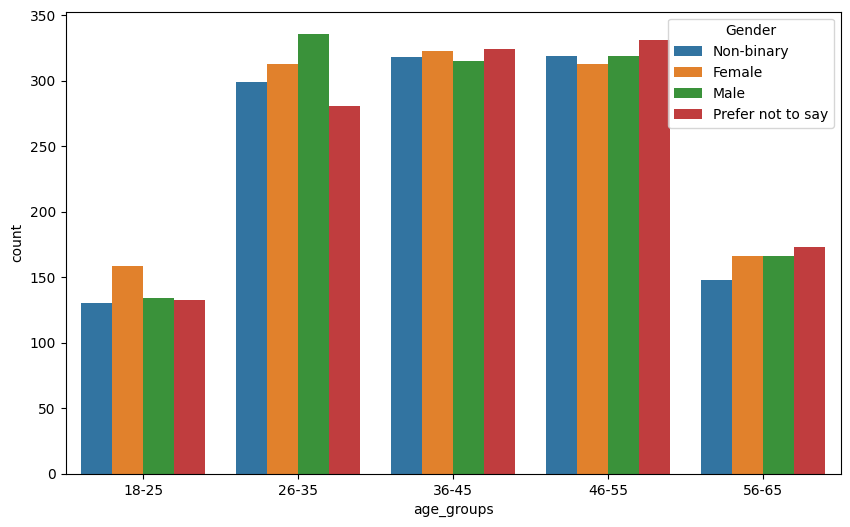

In [27]:
import seaborn as sns 
#distribution of age groups and gender
bins=[18,25,35,45,55,65]
labels=['18-25','26-35','36-45','46-55','56-65']

#Renaming the age groups
gender_mapping={0:''}

df['age_groups']=pd.cut(df['Age'], bins=bins, labels=labels, include_lowest=True)

plt.figure(figsize=(10,6))
sns.countplot(data=df, x='age_groups', hue='Gender')    
plt.title='Distribution of Age'
plt.show()

Looks quite normal like most of people is in working age

### Q2. Year of experiences and mental health conditions

Idea: Showing by bar number of people with year of experiences, line for how many percentage in each plot having mental health problem

In [93]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

def experience_bar_line(df: pd.DataFrame,
                        exp_col="Years_of_Experience",
                        mh_col="Mental_Health_Condition",
                        bins=(0,5,10,15,20,100),
                        labels=("0–5 yrs","6–10 yrs","11–15 yrs","16–20 yrs","21+ yrs"),
                        title="Experience vs Mental Health Condition"):
    # 1) Bin experience
    d = df[[exp_col, mh_col]].copy()
    d["Experience_Range"] = pd.cut(d[exp_col], bins=bins, labels=labels, right=True, include_lowest=True)

    # 2) Denominator: total per bin
    den = d.groupby("Experience_Range", observed=True).size().reindex(labels, fill_value=0)

    # 3) Numerator: count of non-"None" per bin
    num = (d.assign(has_mh = d[mh_col].ne("No Condition").astype(int))
             .groupby("Experience_Range", observed=True)["has_mh"]
             .sum()
             .reindex(labels, fill_value=0))

    # 4) Percent with condition per bin
    pct = (num / den.replace(0, np.nan) * 100).fillna(0)

    # 5) Build figure
    fig = go.Figure()

    bar_color  = "#6AA9FF"   # blue
    line_color = "#1E2E4F"   # dark blue

    fig.add_trace(go.Bar(
        x=list(labels),
        y=den.values.astype(int),
        name="Number of people",
        marker_color=bar_color,
        hovertemplate="Range: %{x}<br>Count: %{y}<extra></extra>"
    ))

    fig.add_trace(go.Scatter(
        x=list(labels),
        y=pct.values,
        name="% with mental health condition",
        mode="lines+markers+text",
        yaxis="y2",
        line=dict(color=line_color, width=3),
        marker=dict(color=line_color, size=8),
        text=[f"{v:.1f}%" for v in pct.values],
        textposition="top center",
        hovertemplate="Range: %{x}<br>% with condition: %{y:.1f}%<extra></extra>"
    ))

    fig.update_layout(
        title=title,
        template="simple_white",
        xaxis=dict(title="Years of Experience"),
        yaxis=dict(title="Number of people", gridcolor="rgba(0,0,0,0.08)"),
        yaxis2=dict(title="% with condition", overlaying="y", side="right", ticksuffix="%", rangemode="tozero"),
        legend=dict(orientation="h", y=1.12),
        margin=dict(l=50, r=50, t=70, b=50)
    )
    return fig


In [94]:
fig = experience_bar_line(df)
fig.show()

A lot of people are senior with 20+ years of experience. But most of them have mental health problem, higest in group 0-5 years, junior

Im looking patterns between similar plot and stress level

In [96]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

def experience_bar_line_stress(
    df: pd.DataFrame,
    exp_col: str = "Years_of_Experience",
    stress_col: str = "Stress_Level",          # expects values like "Low","Medium","High"
    focus_level: str = "High",                 # which stress level to plot on the line
    bins=(0,5,10,15,20,100),
    labels=("0–5 yrs","6–10 yrs","11–15 yrs","16–20 yrs","21+ yrs"),
    title: str = "Experience vs Stress (Counts + % with selected level)"
):
    # 1) Bin experience
    d = df[[exp_col, stress_col]].dropna().copy()
    d["Experience_Range"] = pd.cut(d[exp_col], bins=bins, labels=labels,
                                   right=True, include_lowest=True)

    # 2) Denominator per bin (everyone in that bin)
    den = (d.groupby("Experience_Range", observed=True)
             .size().reindex(labels, fill_value=0))

    # 3) Numerator: count of rows with the chosen stress level in each bin
    num = (d.assign(hit = d[stress_col].astype(str).str.strip().str.lower()
                      == str(focus_level).strip().lower())
             .groupby("Experience_Range", observed=True)["hit"]
             .sum().reindex(labels, fill_value=0))

    # 4) Percent within bin
    pct = (num / den.replace(0, np.nan) * 100).fillna(0)

    # 5) Build figure (bars + secondary-axis line)
    fig = go.Figure()

    bar_color  = "#6AA9FF"   # blue
    line_color = "#1E2E4F"   # dark blue

    fig.add_trace(go.Bar(
        x=list(labels),
        y=den.values.astype(int),
        name="Number of people",
        marker_color=bar_color,
        hovertemplate="Range: %{x}<br>Count: %{y}<extra></extra>"
    ))

    fig.add_trace(go.Scatter(
        x=list(labels),
        y=pct.values,
        name=f"% with {focus_level} stress",
        mode="lines+markers+text",
        yaxis="y2",
        line=dict(color=line_color, width=3),
        marker=dict(color=line_color, size=8),
        text=[f"{v:.1f}%" for v in pct.values],
        textposition="top center",
        hovertemplate=f"Range: %{ { 'x' } }<br>% with {focus_level}: %{{y:.1f}}%<extra></extra>"
    ))

    fig.update_layout(
        title=f"{title} — Focus: {focus_level}",
        template="simple_white",
        xaxis=dict(title="Years of Experience"),
        yaxis=dict(title="Number of people", gridcolor="rgba(0,0,0,0.08)"),
        yaxis2=dict(title="% with selected stress level", overlaying="y",
                    side="right", ticksuffix="%", rangemode="tozero"),
        legend=dict(orientation="h", y=1.12),
        margin=dict(l=50, r=50, t=80, b=50)
    )
    return fig


In [97]:
# High-stress focus (default)
fig = experience_bar_line_stress(df, focus_level="High")
fig.show()


In [98]:
# Or look at Medium / Low stress
fig = experience_bar_line_stress(df, focus_level="Medium")
fig.show()

Lets look at these plots with sastifaction

In [99]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

def experience_bar_line_satisfaction(
    df: pd.DataFrame,
    exp_col: str = "Years_of_Experience",
    sat_col: str = "Satisfaction_with_Remote_Work",   # values like "Unsatisfied","Neutral","Satisfied"
    focus_level: str = "Satisfied",                    # pick: "Satisfied" | "Neutral" | "Unsatisfied"
    bins=(0,5,10,15,20,100),
    labels=("0–5 yrs","6–10 yrs","11–15 yrs","16–20 yrs","21+ yrs"),
    title: str = "Experience vs Satisfaction (Counts + % with selected level)"
):
    # 1) Bin experience
    d = df[[exp_col, sat_col]].dropna().copy()
    d["Experience_Range"] = pd.cut(d[exp_col], bins=bins, labels=labels,
                                   right=True, include_lowest=True)

    # 2) Denominator per bin
    den = (d.groupby("Experience_Range", observed=True)
             .size().reindex(labels, fill_value=0))

    # 3) Numerator per bin for chosen satisfaction level
    target = str(focus_level).strip().lower()
    num = (d.assign(hit = d[sat_col].astype(str).str.strip().str.lower() == target)
             .groupby("Experience_Range", observed=True)["hit"]
             .sum().reindex(labels, fill_value=0))

    # 4) Percent within bin
    pct = (num / den.replace(0, np.nan) * 100).fillna(0)

    # 5) Build figure
    fig = go.Figure()

    bar_color  = "#6AA9FF"   # blue
    line_color = "#1E2E4F"   # dark blue

    fig.add_trace(go.Bar(
        x=list(labels),
        y=den.values.astype(int),
        name="Number of people",
        marker_color=bar_color,
        hovertemplate="Range: %{x}<br>Count: %{y}<extra></extra>"
    ))

    fig.add_trace(go.Scatter(
        x=list(labels),
        y=pct.values,
        name=f"% {focus_level}",
        mode="lines+markers+text",
        yaxis="y2",
        line=dict(color=line_color, width=3),
        marker=dict(color=line_color, size=8),
        text=[f"{v:.1f}%" for v in pct.values],
        textposition="top center",
        hovertemplate=f"Range: %{{x}}<br>% {focus_level}: %{{y:.1f}}%<extra></extra>"
    ))

    fig.update_layout(
        title=f"{title} — Focus: {focus_level}",
        template="simple_white",
        xaxis=dict(title="Years of Experience"),
        yaxis=dict(title="Number of people", gridcolor="rgba(0,0,0,0.08)"),
        yaxis2=dict(title=f"% {focus_level}", overlaying="y", side="right", ticksuffix="%", rangemode="tozero"),
        legend=dict(orientation="h", y=1.12),
        margin=dict(l=50, r=50, t=80, b=50)
    )
    return fig


In [100]:
# % satisfied by experience
fig = experience_bar_line_satisfaction(df, focus_level="Satisfied")
fig.show()

In [101]:
# % unsatisfied
fig = experience_bar_line_satisfaction(df, focus_level="Unsatisfied")
fig.show()

And with productivity change

In [110]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

def experience_bar_line_productivity_change(
    df: pd.DataFrame,
    exp_col: str = "Years_of_Experience",
    prod_col: str = "Productivity_Change",     # <- uses Increase / Decrease / No Change
    focus_level: str = "Increase",             # choose: "Increase" | "Decrease" | "No Change"
    bins=(0,5,10,15,20,100),
    labels=("0–5 yrs","6–10 yrs","11–15 yrs","16–20 yrs","21+ yrs"),
    title: str = "Experience vs Productivity Change (Counts + % within bin)"
):
    # 1) Bin experience
    d = df[[exp_col, prod_col]].dropna().copy()
    d["Experience_Range"] = pd.cut(d[exp_col], bins=bins, labels=labels,
                                   right=True, include_lowest=True)

    # 2) Denominator per bin
    den = (d.groupby("Experience_Range", observed=True)
             .size().reindex(labels, fill_value=0))

    # 3) Numerator per bin for chosen productivity change
    target = str(focus_level).strip().lower()
    num = (d.assign(hit = d[prod_col].astype(str).str.strip().str.lower() == target)
             .groupby("Experience_Range", observed=True)["hit"]
             .sum().reindex(labels, fill_value=0))

    # 4) Percent within each bin
    pct = (num / den.replace(0, np.nan) * 100).fillna(0)

    # 5) Build figure (bars = counts; line = % with chosen change)
    fig = go.Figure()

    fig.add_trace(go.Bar(
        x=list(labels),
        y=den.values.astype(int),
        name="Number of people",
        marker_color="#A8C5FF",
        hovertemplate="Range: %{x}<br>Count: %{y}<extra></extra>"
    ))

    fig.add_trace(go.Scatter(
        x=list(labels),
        y=pct.values,
        name=f"% {focus_level}",
        mode="lines+markers+text",
        yaxis="y2",
        line=dict(color="#1E2E4F", width=3),
        marker=dict(color="#1E2E4F", size=8),
        text=[f"{v:.1f}%" for v in pct.values],
        textposition="top center",
        hovertemplate=f"Range: %{{x}}<br>% {focus_level}: %{{y:.1f}}%<extra></extra>"
    ))

    fig.update_layout(
        title=f"{title} — Focus: {focus_level}",
        template="simple_white",
        xaxis=dict(title="Years of Experience"),
        yaxis=dict(title="Number of people", gridcolor="rgba(0,0,0,0.08)"),
        yaxis2=dict(title=f"% {focus_level}", overlaying="y", side="right",
                    ticksuffix="%", rangemode="tozero"),
        legend=dict(orientation="h", y=1.12),
        margin=dict(l=50, r=50, t=80, b=50)
    )
    return fig


In [111]:
# % with productivity Decrease
fig = experience_bar_line_productivity_change(df, focus_level="Decrease")
fig.show()

#### Q2: Job_Role has the highest prevalence of Mental_Health_Condition (Anxiety/Burnout/Depression), and does it vary by Gender?

In [95]:

import plotly.express as px

# ---- 1) Clean labels ----
dfc = df.copy()
for col in ["Job_Role", "Gender", "Mental_Health_Condition"]:
    dfc[col] = dfc[col].astype("string").str.strip().str.title()

dfc["Mental_Health_Condition"] = dfc["Mental_Health_Condition"].replace({
    "No Condition": "None", "Nan": "None", "Null": "None"
})

# order for the stack
cond_order = ["Anxiety", "Burnout", "Depression", "None"]

# (optional) keep top N roles so the plot stays readable
TOP_N_ROLES = 12
role_order = dfc["Job_Role"].value_counts().head(TOP_N_ROLES).index.tolist()
sub = dfc[dfc["Job_Role"].isin(role_order) & dfc["Gender"].notna()]

# ---- 2) Aggregate to % within each Gender + Job_Role ----
g = (
    sub.groupby(["Gender", "Job_Role", "Mental_Health_Condition"], as_index=False)
       .size()
       .rename(columns={"size": "count"})
)
g["percent"] = g["count"] / g.groupby(["Gender", "Job_Role"])["count"].transform("sum") * 100

# categorical ordering for consistent display
g["Job_Role"] = pd.Categorical(g["Job_Role"], categories=role_order, ordered=True)
g["Mental_Health_Condition"] = pd.Categorical(g["Mental_Health_Condition"],
                                              categories=cond_order, ordered=True)

# ---- 3) Plot: stacked % bars, faceted by Gender ----
fig = px.bar(
    g, x="Job_Role", y="percent", color="Mental_Health_Condition",
    facet_col="Gender", facet_col_wrap=2,
    category_orders={"Job_Role": role_order, "Mental_Health_Condition": cond_order},
    labels={"percent": "% within role", "Job_Role": "Job role"},
    title="Mental-Health Condition by Job Role and Gender (stacked %)"
)
fig.update_layout(barmode="stack", height=520, legend_title="Condition",
                  margin=dict(t=60, r=20, b=60, l=60))
fig.update_xaxes(tickangle=45)
# simplify facet labels (show only gender value)
fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))
fig.show()

# ---- (Optional) table: top roles by 'any condition' prevalence within each gender ----
any_cond = g[g["Mental_Health_Condition"].isin(["Anxiety","Burnout","Depression"])].copy()
top_any = (
    any_cond.groupby(["Gender","Job_Role"], as_index=False)["percent"].sum()
            .sort_values(["Gender","percent"], ascending=[True, False])
)
top_any.groupby("Gender").head(5)  # preview


/var/folders/7m/_vb5phg50tdbns11bkg8wskr0000gn/T/ipykernel_54705/2863372601.py:51: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,Gender,Job_Role,percent
5,Female,Data Scientist,81.372549
0,Female,Project Manager,78.823529
3,Female,Hr,77.094972
1,Female,Sales,75.647668
4,Female,Software Engineer,73.714286
10,Male,Hr,83.798883
12,Male,Data Scientist,83.229814
7,Male,Project Manager,79.000000
8,Male,Sales,78.571429
11,Male,Software Engineer,75.675676


- Across genders, the split by role looks broadly similar, no role jumps out as an extreme outlier. That suggests mental-health risk is not confined to one job family.
- Differences that seem present are small (e.g., a touch more Burnout in people-facing roles like HR/Sales/PM, and a bit more “None” in some technical roles)


#### Q3. How does Stress_Level differ by Work_Location (Remote/Hybrid/Onsite) and Number_of_Virtual_Meetings?

In [29]:

# --- clean + bins ---
dfc = df.copy()

# tidy labels
dfc["Mental_Health_Condition"] = (
    dfc["Mental_Health_Condition"].astype("string").str.strip().str.title()
    .replace({"No Condition": "None", "Nan": "None", "Null": "None"})
)

# bins you can tweak if needed
hours_bins = pd.cut(
    dfc["Hours_Worked_Per_Week"],
    bins=[0, 35, 40, 45, 50, 60, np.inf],
    labels=["<35", "35–40", "40–45", "45–50", "50–60", "60+"],
    include_lowest=True, right=False
)
meet_bins = pd.cut(
    dfc["Number_of_Virtual_Meetings"],
    bins=[-np.inf, 2, 5, 8, np.inf],
    labels=["0–2", "3–5", "6–8", "9+"]
)

dfc = dfc.assign(hours_bin=hours_bins, meet_bin=meet_bins)
dfc = dfc.dropna(subset=["hours_bin", "meet_bin"])

# --- (1) HEATMAP: % with ANY condition ---
any_mask = dfc["Mental_Health_Condition"].isin(["Anxiety", "Burnout", "Depression"])
heat = (
    dfc.assign(any_condition=any_mask)
       .groupby(["meet_bin", "hours_bin"], as_index=False)["any_condition"]
       .mean()
       .assign(pct=lambda d: d["any_condition"] * 100)
)

heat_pivot = heat.pivot(index="meet_bin", columns="hours_bin", values="pct")
fig1 = px.imshow(
    heat_pivot,
    text_auto=".1f", aspect="auto", origin="lower",
    color_continuous_scale="RdBu_r",  # blue=low, red=high
    labels=dict(color="% with condition"),
    title="Any Mental-Health Condition by Hours Worked × Virtual Meetings (%)"
)
fig1.update_layout(height=420, margin=dict(t=60, l=40, r=20, b=40))
fig1.show()

# --- (2) STACKED % BARS: full split by condition, faceted by meetings ---
order_cond = ["Anxiety", "Burnout", "Depression", "None"]
g = (
    dfc.groupby(["meet_bin", "hours_bin", "Mental_Health_Condition"], as_index=False)
       .size()
       .rename(columns={"size": "n"})
)
g["pct"] = g["n"] / g.groupby(["meet_bin", "hours_bin"])["n"].transform("sum") * 100
g["Mental_Health_Condition"] = pd.Categorical(g["Mental_Health_Condition"], order_cond, ordered=True)

fig2 = px.bar(
    g, x="hours_bin", y="pct", color="Mental_Health_Condition",
    facet_col="meet_bin", category_orders={
        "hours_bin": list(hours_bins.cat.categories),
        "Mental_Health_Condition": order_cond,
    },
    labels={"hours_bin": "Hours / week", "pct": "% within cell", "Mental_Health_Condition": "Condition"},
    title="Mental-Health Condition split by Hours Worked (faceted by Virtual Meetings)"
)
fig2.update_layout(barmode="stack", height=520, margin=dict(t=60, l=40, r=20, b=60))
fig2.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))  # simplify facet titles
fig2.show()


/var/folders/7m/_vb5phg50tdbns11bkg8wskr0000gn/T/ipykernel_54705/714674770.py:30: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



/var/folders/7m/_vb5phg50tdbns11bkg8wskr0000gn/T/ipykernel_54705/714674770.py:49: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/var/folders/7m/_vb5phg50tdbns11bkg8wskr0000gn/T/ipykernel_54705/714674770.py:53: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



- Risk rises with hours, especially 60+ hrs/week, where “any condition” often exceeds 80–90%.
- Meeting load is curvy: 3–5 meetings/week tends to show lower risk, while very few (0–2) or many (6–8/9+) meetings are associated with higher risk at the same hours.
- At high hours, the share of “None” drops and Burnout/Depression grow, consistent with overload.
- The single low cell at 60+ hrs & 3–5 meetings (~60%) looks anomalous, likely small N


### Q5. How big is the effect of hours?

This a bit move to diagnosistic, so i will stop here and move to another notebook soon!

In [30]:
%pip install -q statsmodels

Note: you may need to restart the kernel to use updated packages.


In [31]:
import numpy as np, pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import plotly.express as px

# ---- settings (EDIT if your meetings column has a different name)
MEET_COL = "Number_of_Virtual_Meetings"   # e.g. "Virtual_Meetings" if needed

# ---- minimal prep
dfc = df.copy()
dfc["any_condition"] = (
    dfc["Mental_Health_Condition"].astype(str).str.strip().str.title()
    .isin(["Anxiety","Burnout","Depression"]).astype(int)
)
dfc["hours_per_5"] = pd.to_numeric(dfc["Hours_Worked_Per_Week"], errors="coerce")/5
dfc[MEET_COL] = pd.to_numeric(dfc[MEET_COL], errors="coerce")
dfc["meet_bin"] = pd.cut(dfc[MEET_COL], [-np.inf,2,5,8,np.inf], labels=["0–2","3–5","6–8","9+"])

# make categoricals light-weight
for c in ["Gender","Job_Role","Industry","meet_bin"]:
    dfc[c] = dfc[c].astype("category")

model_df = dfc.dropna(subset=["any_condition","hours_per_5","meet_bin","Gender","Job_Role","Industry"])

# ---- logistic regression (odds ratio per +5 hours), controlling for covariates
fit = smf.glm(
    "any_condition ~ hours_per_5 + C(meet_bin) + C(Gender) + C(Job_Role) + C(Industry)",
    data=model_df, family=sm.families.Binomial()
).fit()

b  = fit.params["hours_per_5"]
se = fit.bse["hours_per_5"]
OR = float(np.exp(b))
lo = float(np.exp(b - 1.96*se))
hi = float(np.exp(b + 1.96*se))
p  = fit.pvalues["hours_per_5"]
print(f"Odds ratio for +5 hours/week: {OR:.2f} (95% CI {lo:.2f}–{hi:.2f}), p={p:.4g}")

# ---- quick marginal lines (no CI): predicted risk vs hours, per meetings bin
hours_grid = np.arange(30, 66, 5)

typ_gender = model_df["Gender"].mode().iloc[0]
typ_role   = model_df["Job_Role"].mode().iloc[0]
typ_ind    = model_df["Industry"].mode().iloc[0]

rows = []
for m in model_df["meet_bin"].cat.categories:
    for h in hours_grid:
        new = pd.DataFrame([{
            "hours_per_5": h/5.0, "meet_bin": m,
            "Gender": typ_gender, "Job_Role": typ_role, "Industry": typ_ind
        }])
        prob = float(fit.predict(new))
        rows.append({"meet_bin": str(m), "hours": h, "pred_%": prob*100})

pred = pd.DataFrame(rows)
fig = px.line(pred, x="hours", y="pred_%", color="meet_bin",
              labels={"hours":"Hours / week","pred_%":"Predicted probability (%)","meet_bin":"Meetings"},
              title="Predicted probability vs hours (controls held typical)")
fig.update_layout(height=400, margin=dict(t=50,r=20,b=40,l=50))
fig.show()


Odds ratio for +5 hours/week: 1.01 (95% CI 0.98–1.04), p=0.4051


/var/folders/7m/_vb5phg50tdbns11bkg8wskr0000gn/T/ipykernel_54705/1114115938.py:53: FutureWarning:

Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead

/var/folders/7m/_vb5phg50tdbns11bkg8wskr0000gn/T/ipykernel_54705/1114115938.py:53: FutureWarning:

Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead

/var/folders/7m/_vb5phg50tdbns11bkg8wskr0000gn/T/ipykernel_54705/1114115938.py:53: FutureWarning:

Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead

/var/folders/7m/_vb5phg50tdbns11bkg8wskr0000gn/T/ipykernel_54705/1114115938.py:53: FutureWarning:

Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead

/var/folders/7m/_vb5phg50tdbns11bkg8wskr0000gn/T/ipykernel_54705/1114115938.py:53: Futur

Hours effect is tiny. Meetings matter more. Curves are vertically separated by meeting bands

### Q6. Verify Hours×Meetings interaction

In [32]:
import numpy as np, pandas as pd
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

# ---- minimal prep (edit the meetings column name if needed)
MEET_COL = "Number_of_Virtual_Meetings"   # change if yours is different

dfc = df.copy()
dfc["any_condition"] = (
    dfc["Mental_Health_Condition"].astype(str).str.strip().str.title()
      .isin(["Anxiety","Burnout","Depression"]).astype(int)
)
dfc["hours_per_5"] = pd.to_numeric(dfc["Hours_Worked_Per_Week"], errors="coerce")/5
dfc[MEET_COL] = pd.to_numeric(dfc[MEET_COL], errors="coerce")

# use ASCII labels to keep param names clean; set "0-2" as reference
labels = ["0-2","3-5","6-8","9+"]
dfc["meet_bin"] = pd.cut(dfc[MEET_COL], [-np.inf,2,5,8,np.inf], labels=labels, include_lowest=True).astype("category")
dfc["meet_bin"] = dfc["meet_bin"].cat.reorder_categories(labels, ordered=True)

for c in ["Gender","Job_Role","Industry"]:
    dfc[c] = dfc[c].astype("category")

model_df = dfc.dropna(subset=["any_condition","hours_per_5","meet_bin","Gender","Job_Role","Industry"])

# ---- models: without vs with interaction (so we can do an LR test)
C_meet = "C(meet_bin, Treatment(reference='0-2'))"
form0  = f"any_condition ~ hours_per_5 + {C_meet} + C(Gender) + C(Job_Role) + C(Industry)"
form1  = f"{form0} + hours_per_5:{C_meet}"

m0 = smf.glm(form0, data=model_df, family=sm.families.Binomial()).fit()
m1 = smf.glm(form1, data=model_df, family=sm.families.Binomial()).fit()

# Likelihood-ratio test for the interaction block
lr_stat = 2 * (m1.llf - m0.llf)
df_diff = int(m1.df_model - m0.df_model)
p_lr = stats.chi2.sf(lr_stat, df_diff)
print(f"Hours×Meetings interaction LR test: χ²({df_diff}) = {lr_stat:.2f}, p = {p_lr:.4g}")

# ---- simple slopes: effect of +5 hours within each meeting bin
cov = m1.cov_params()
base = m1.params["hours_per_5"]

rows = []
for lvl in labels:
    if lvl == "0-2":
        slope = base
        var   = cov.loc["hours_per_5","hours_per_5"]
    else:
        term = f"hours_per_5:{C_meet}[T.{lvl}]"
        slope = base + m1.params.get(term, 0.0)
        var   = (cov.loc["hours_per_5","hours_per_5"]
                 + cov.loc[term, term]
                 + 2*cov.loc["hours_per_5", term])
    se = np.sqrt(var)
    OR = np.exp(slope)
    lo = np.exp(slope - 1.96*se)
    hi = np.exp(slope + 1.96*se)
    p  = 2*stats.norm.sf(abs(slope/se))
    rows.append({"Meetings": lvl, "OR per +5 hours": OR, "CI_low": lo, "CI_high": hi, "p": p})

slopes = pd.DataFrame(rows)
slopes


Hours×Meetings interaction LR test: χ²(3) = 2.41, p = 0.4922


,Meetings,OR per +5 hours,CI_low,CI_high,p
0,0-2,1.051676,0.985896,1.121846,0.126275
1,3-5,1.026095,0.961193,1.095379,0.439682
2,6-8,0.986812,0.925213,1.052511,0.686425
3,9+,1.000725,0.960529,1.042602,0.972370


LR test for Hours×Meetings: χ²(3)=2.41, p=0.49 → the interaction block isn’t significant.

In [33]:
form_lin = "any_condition ~ hours_per_5 + C(meet_bin) + C(Gender)+C(Job_Role)+C(Industry)"
form_quad = "any_condition ~ hours_per_5 + I(hours_per_5**2) + C(meet_bin) + C(Gender)+C(Job_Role)+C(Industry)"
m_lin = smf.glm(form_lin, data=model_df, family=sm.families.Binomial()).fit()
m_quad = smf.glm(form_quad, data=model_df, family=sm.families.Binomial()).fit()
from scipy import stats
lr = 2*(m_quad.llf - m_lin.llf); df = m_quad.df_model - m_lin.df_model
print("Quadratic hours LR test:", lr, "p=", stats.chi2.sf(lr, df))


Quadratic hours LR test: 0.009765753738975036 p= 0.9212797368860679
